In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif']=['SimHei']
plt.rcParams['axes.unicode_minus']=False

df = pd.read_csv("train.csv")
df.head()
print(df.shape)
print(df.dtypes)
print(df.isna().sum())

(891, 12)
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [23]:
# df.drop(columns=['Cabin', 'Name', 'Ticket', 'PassengerId'], inplace=True)
# df['Age'] = df['Age'].fillna(df['Age'].median(), inplace=True)
# df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
# print(df.isna().sum())
# print("清洗后的数据：")
# print(df.shape)
# df.head()

df = pd.read_csv("train.csv")
df.drop(columns=['Cabin','Name','Ticket','PassengerId'], inplace=True)
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
print(df.isna().sum())  # 确认全为0

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [24]:
# 1.总体生存率是多少？
print(f"总体生存率是:{df['Survived'].mean()*100:.1f}%")
# 2.男女生存率各是多少？
print(df.groupby('Sex')['Survived'].mean())
# 3.各舱位等级（Pclass）生存率是多少？
print(df.groupby('Pclass')['Survived'].mean())

总体生存率是:38.4%
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


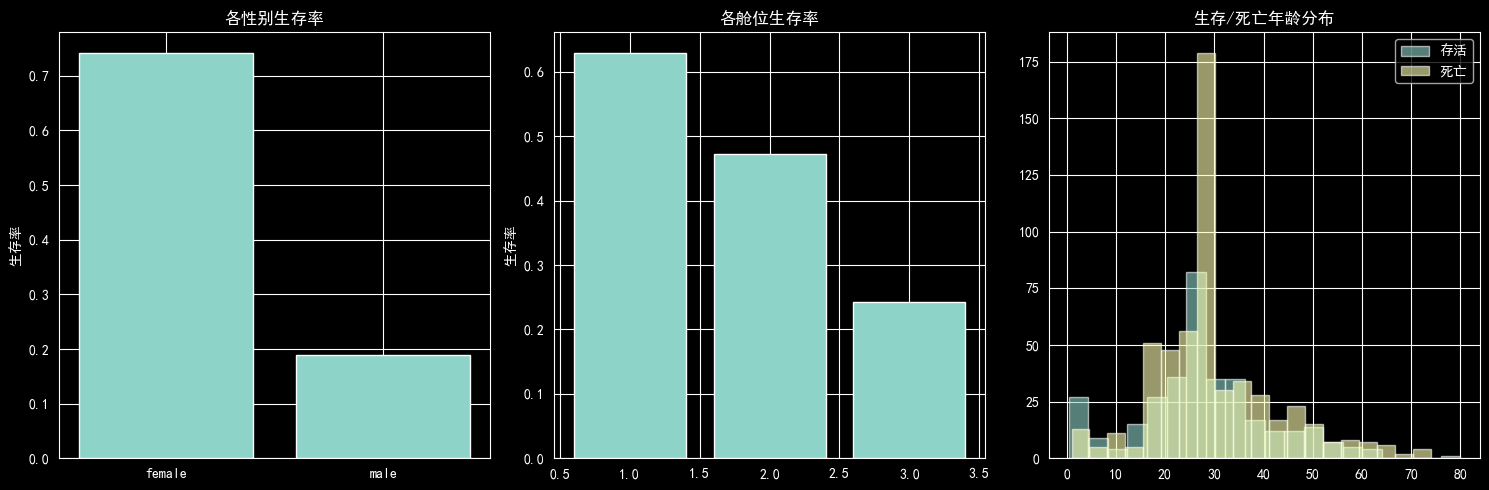

In [25]:
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sex_survival = df.groupby('Sex')['Survived'].mean()
axes[0].bar(sex_survival.index, sex_survival.values)
axes[0].set_title('各性别生存率')
axes[0].set_ylabel('生存率')

pclass_survival = df.groupby('Pclass')['Survived'].mean()
axes[1].bar(pclass_survival.index, pclass_survival.values)
axes[1].set_title('各舱位生存率')
axes[1].set_ylabel('生存率')

# sns.histplot(data=df, x='Age', hue=df['Survived'].astype(str), ax=axes[2])
# axes[2].set_title('生存/死亡年龄分布')
survived = df[df['Survived'] == 1]['Age'].dropna()
died = df[df['Survived'] == 0]['Age'].dropna()
axes[2].hist(survived, alpha=0.6, label='存活', bins=20)
axes[2].hist(died, alpha=0.6, label='死亡', bins=20)
axes[2].set_title('生存/死亡年龄分布')
axes[2].legend()

plt.tight_layout()
plt.show()




## 分析结论

**1. 性别是最关键的生存因素**
女性生存率74%，男性仅19%，差距悬殊。

**2. 舱位等级与生存率强相关**
头等舱63% > 二等舱47% > 三等舱24%
经济条件越好，生存机会越大。

**3. 年龄影响相对较小**
20岁到30岁的死亡人数特别多，存活和死亡的年龄分布差异不算特别大，说明年龄不是最关键的因素。

In [7]:



import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

df = pd.read_csv("train.csv")
df['Sex']=df['Sex'].map({'male':0,'female':1})
df['Embarked']=df['Embarked'].map({'S':0,'C':1,'Q':2})
df['Age']=df['Age'].fillna(df['Age'].median())
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])
X=df[['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']]
y=df['Survived']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(f'训练集大小：{X_train.shape}')
print(f'测试集大小：{X_test.shape}')
# 训练模型
model=LogisticRegression(max_iter=200)
model.fit(X_train,y_train)
# 预测
y_pred=model.predict(X_test)
# 看准确率
accuracy=accuracy_score(y_test,y_pred)
print(f'模型准确率:{accuracy*100:.1f}%')

feature_names=['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']
coefficients=model.coef_[0]
for name,coef in zip(feature_names,coefficients):
    print(f'{name}:{coef:.3f}')



训练集大小：(712, 7)
测试集大小：(179, 7)
模型准确率:79.9%
Pclass:-0.958
Sex:2.584
Age:-0.031
SibSp:-0.303
Parch:-0.101
Fare:0.003
Embarked:0.221
